# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [67]:
!uv pip install -r ../requirements.txt

Using Python 3.14.3 environment at: /home/victorhugo/obi-benchmarking/.venv
Checked 10 packages in 6ms


In [68]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import re
from IPython.display import display

In [69]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    print(folder)
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
questions_name = []
for question_path in questions_path:
    questions_name.append(question_path.name)
    problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))

../database/Caça ao Tesouro_2011
../database/Gomoku
../database/Imagens de Satélite
../database/Notas da Prova
../database/Jogo da Vida
../database/Muro
../database/O Chefe
../database/Lâmpadas do hotel
../database/Polígono
../database/Proteja sua senha
../database/Chinelos
../database/Hotel
../database/Jogo dos copos
../database/Carnaval
../database/Tiro ao Alvo
../database/Robô_2021
../database/Carga Pesada
../database/Transportes
../database/Álbum da copa
../database/Jogo de Dominós
../database/Arco e flecha
../database/Autorama
../database/Quadrado Mágico
../database/Jogo de Búzios
../database/Móbile
../database/Quase primo
../database/Lâmpadas
../database/Campo de Minhocas
../database/Divisão do Tesouro
../database/Entrega de Caixas
../database/Coleção de Upas
../database/Cinema
../database/Quadrado Mágico_2007
../database/Fila
../database/Montanha
../database/Chuva
../database/Festa olímpica
../database/Pô, que mão
../database/Aviões de papel
../database/Relógio
../database/Torre

In [70]:
for problem in problems:
    print(problem["title"])

Caça ao Tesouro
Gomoku
Imagens de Satélite
Notas da Prova
Jogo da Vida
Muro
O Chefe
Lâmpadas do hotel
Polígono
Proteja sua senha
Chinelos
Hotel
Jogo dos copos
Carnaval
Tiro ao Alvo
Robô
Carga Pesada
Transportes
Álbum da copa
Jogo de Dominós
Arco e flecha
Autorama
Quadrado Mágico
Jogo de Búzios
Móbile
Quase primo
Lâmpadas
Campo de Minhocas
Divisão do Tesouro
Entrega de Caixas
Coleção de Upas
Cinema
Quadrado Mágico
Fila
Montanha
Chuva
Festa olímpica
Pô, que mão
Aviões de papel
Relógio
Torre
Pão a Metro
Mesa redonda
Sorvete
Expressões
Pizzaria
Par ou ímpar
Pedido de Desculpas
Ortografia
Redes de Descanso
Mancha
Escher
Direção
Nova avenida
Telescópio
Game Show
Manchas de pele
Temperatura Lunar
Castelos da Nlogônia
Matriz Escada
Fusões
Capitais
Quadrado Mágico
Telemarketing
Piloto Automático
Música para Todos
Falta uma
Sanduíche
Palavras Cruzadas
Blefe
Tabela do campeonato
Clube dos Cinco
Lanche na empresa
Piso da escola
Caravana
Janela
Ônibus
Quadrado
Chocolate
Chocolate em barra
Soma de F

In [71]:
output_results_model = pd.read_csv("../output/zero_vs_few/results/results_anthropic_claude_sonnet_4_6_python_few.csv")

df_problems = []

for problem in problems:
    name = problem["title"]
    question_dir = Path('../database') / name
    
    if name in list(output_results_model['question_name']):
        if question_dir.exists():
            df_problems.append(problem)
    
df_problems = pd.DataFrame(df_problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Médio': 118, 'Fácil': 125, 'Difícil': 54}


[125, 118, 54]
['Fácil', 'Médio', 'Difícil']


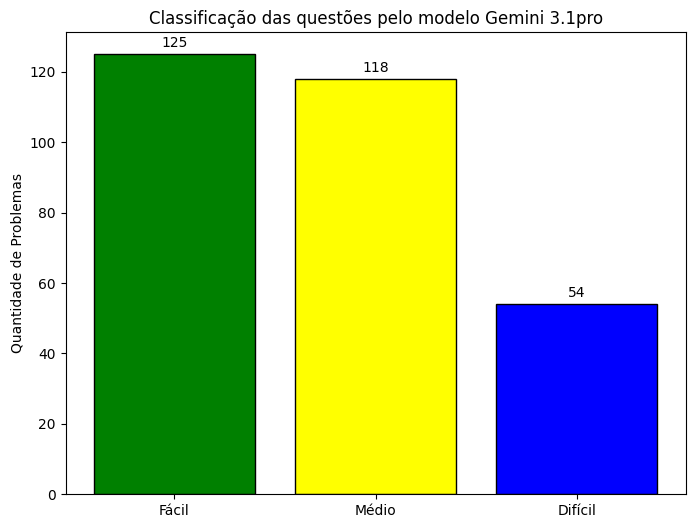

In [72]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Classificação das questões pelo modelo Gemini 3.1pro")
plt.ylabel('Quantidade de Problemas')
plt.show()

In [73]:
questions_by_years = {}

i = 0
for year in df_problems["year"]:
    if questions_by_years.get(year) is None:
        questions_by_years[year] = []
    
    questions_by_years[year].append(i)
    i += 1
        
for key, count in questions_by_years.items():
    print(f"{key}: {len(count)} quantidades")

names_2015 = []

for index in questions_by_years["2015"]:
    names_2015.append(df_problems.iloc[index]["title"])

print(names_2015)

2017: 23 quantidades
2024: 24 quantidades
2018: 28 quantidades
2016: 22 quantidades
2023: 24 quantidades
2022: 24 quantidades
2019: 25 quantidades
2012: 15 quantidades
2013: 8 quantidades
2021: 22 quantidades
2006: 1 quantidades
2007: 1 quantidades
2014: 23 quantidades
2008: 1 quantidades
2015: 14 quantidades
2001: 5 quantidades
2011: 10 quantidades
2010: 6 quantidades
2002: 3 quantidades
2020: 13 quantidades
2025: 1 quantidades
2009: 2 quantidades
2003: 1 quantidades
1999: 1 quantidades
['Torre', 'Capitais', 'Chocolate em barra', 'Fita Colorida', 'Letras', 'Fila', 'Quebra-cabeça', 'Prêmio do Milhão', 'Família real', 'Mina', 'Cálculo', 'Cobra coral', 'Arquivos', 'Código']


### ZERO-SHOT vs FEW-SHOT
---

In [74]:
files_path = Path("../output/zero_vs_few/results/")
dataset = {}
configs = ['_python_few', '_python_zero', '_cpp_few', '_cpp_zero']

for config in configs:
    for path in files_path.rglob('*'):
        if not path.is_file():
            continue

        parts = str(path).split("results_")
        if len(parts) < 2:
            continue

        model = parts[1]
        #print(model)
        data = pd.read_csv(path)

        df_name_2015 = pd.DataFrame()

        for i, name in enumerate(data["question_name"]):
            if name.split("_2015")[0] in names_2015:
                df_name_2015 = pd.concat([df_name_2015, data.iloc[[i]]])

        if not df_name_2015.empty:
            dataset[model] = df_name_2015

count = 0
for data in dataset["gpt_5_4_2026_03_05_python_few.csv"]["total_test_cases"]:
    count += data

print(f"Total de casos de teste: {count}")

Total de casos de teste: 439


In [75]:
rows = []
for model, data in dataset.items():
    rows.append({
        "Modelo": model,
        "AC":  data["AC"].sum()  / count,
        "WA":  data["WA"].sum()  / count,
        "RE":  data["RE"].sum()  / count,
        "TLE": data["TLE"].sum() / count,
        "CE":  data["CE"].sum()  / count,
    })

df_results = pd.DataFrame(rows)

display(
    df_results.style
    .format({
        "AC":  "{:.2%}",
        "WA":  "{:.2%}",
        "RE":  "{:.2%}",
        "TLE": "{:.2%}",
        "CE":  "{:.2%}",
    })
)

,Modelo,AC,WA,RE,TLE,CE
0,mistralai_mistral_small_2603_python_few.csv,58.54%,31.44%,5.01%,5.01%,0.00%
1,stepfun_step_3_5_flash_free_cpp_few.csv,92.03%,0.00%,0.00%,0.00%,0.00%
2,gpt_5_4_2026_03_05_python_few.csv,69.25%,19.82%,5.01%,5.92%,0.00%
3,deepseek_deepseek_v3_2_cpp_few.csv,76.54%,17.08%,2.73%,3.19%,0.00%
4,deepseek_deepseek_v3_2_cpp_zero.csv,74.49%,18.22%,0.00%,6.83%,0.00%
5,anthropic_claude_sonnet_4_6_python_few.csv,78.82%,9.34%,11.85%,0.00%,0.00%
6,x_ai_grok_code_fast_1_python_zero.csv,88.61%,5.47%,0.00%,5.47%,0.00%
7,z_ai_glm_5_python_few.csv,86.56%,2.51%,5.01%,5.92%,0.00%
8,mistralai_mistral_small_2603_cpp_zero.csv,53.99%,30.98%,0.00%,5.92%,8.66%
9,z_ai_glm_5_python_zero.csv,86.56%,2.51%,4.56%,5.92%,0.00%


In [76]:
def parse_model_name(filename):
    name = filename.replace(".csv", "")
    
    lang = "C++" if "_cpp_" in name else "Python"
    shot = "Few-Shot" if "_few" in name else "Zero-Shot"
    
    # Remove sufixos de config
    model = re.sub(r"_(python|cpp)_(few|zero)$", "", name)
    
    return model, lang, shot

rows = []
for model_file, data in dataset.items():
    model, lang, shot = parse_model_name(model_file)
    rows.append({
        "Modelo": model.replace("_", " "),
        "Linguagem": lang,
        "Prompt": shot,
        "AC":  data["AC"].sum()  / count,
        "WA":  data["WA"].sum()  / count,
        "RE":  data["RE"].sum()  / count,
        "TLE": data["TLE"].sum() / count,
        "CE":  data["CE"].sum()  / count,
    })

df_results = pd.DataFrame(rows)

In [77]:
pivot = df_results.pivot_table(
    index="Modelo",
    columns=["Linguagem", "Prompt"],
    values="AC"
).round(4)

display(
    pivot.style
    .format("{:.2%}")
)

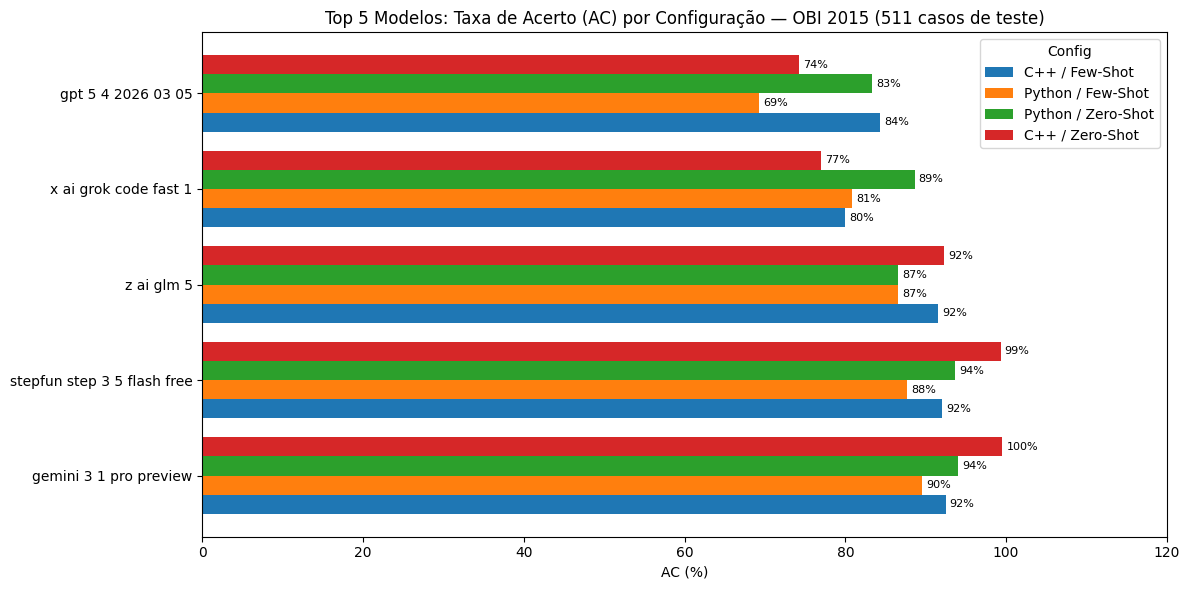

In [78]:
# Top 5 modelos pela média de AC entre todas as configs
top5_models = (
    df_results.groupby("Modelo")["AC"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = df_results[df_results["Modelo"].isin(top5_models)]

fig, ax = plt.subplots(figsize=(12, 6))  # menor pois são só 5 modelos

configs = df_top5[["Linguagem", "Prompt"]].drop_duplicates()
models = top5_models
y = np.arange(len(models))
height = 0.2

for i, (_, cfg) in enumerate(configs.iterrows()):
    subset = df_top5[
        (df_top5["Linguagem"] == cfg.Linguagem) &
        (df_top5["Prompt"] == cfg.Prompt)
    ].set_index("Modelo")["AC"].reindex(models).fillna(0)

    bars = ax.barh(y + i * height, subset * 100, height, label=f"{cfg.Linguagem} / {cfg.Prompt}")

    for bar, val in zip(bars, subset * 100):
        if val > 0:
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%",
                ha="left", va="center", fontsize=8
            )

ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel("AC (%)")
ax.set_title("Top 5 Modelos: Taxa de Acerto (AC) por Configuração — OBI 2015 (511 casos de teste)")
ax.legend(title="Config")
ax.set_xlim(0, 120)
ax.grid(False)

plt.tight_layout()
plt.show()

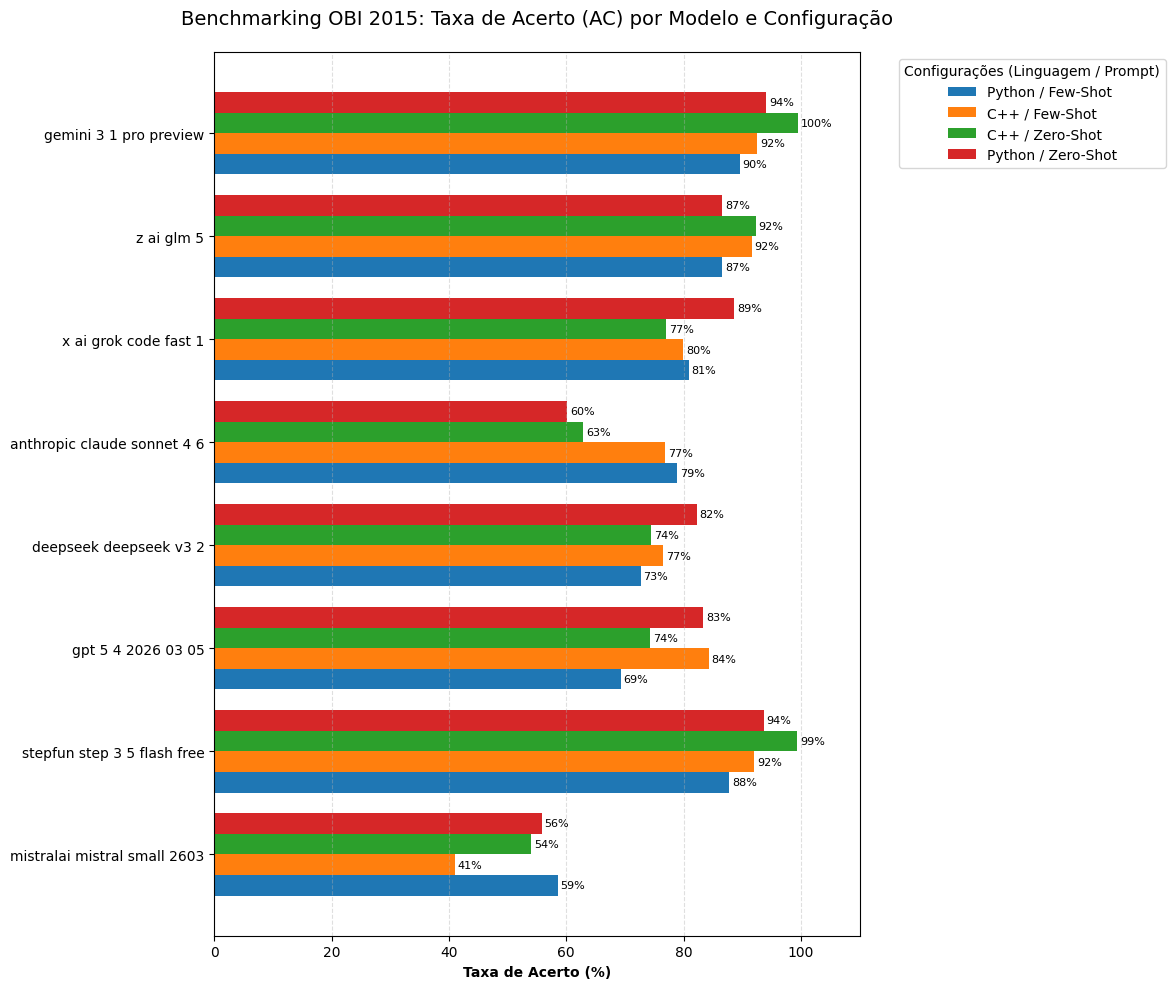

In [79]:
fig, ax = plt.subplots(figsize=(12, 10))

configs = df_results[["Linguagem", "Prompt"]].drop_duplicates()
models = df_results["Modelo"].unique()


y_indices = np.arange(len(models))
bar_height = 0.2
offset = 0 

for i, (_, cfg) in enumerate(configs.iterrows()):
    subset = df_results[
        (df_results["Linguagem"] == cfg.Linguagem) & 
        (df_results["Prompt"] == cfg.Prompt)
    ].set_index("Modelo")["AC"].reindex(models).fillna(0)
    
    current_y = y_indices + (i * bar_height)
    label_text = f"{cfg.Linguagem} / {cfg.Prompt}"
    
    bars = ax.barh(current_y, subset * 100, bar_height, label=label_text)
    
    for bar in bars:
        width = bar.get_width()
        if width > 0:
            ax.text(
                width + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.0f}%", 
                ha="left", 
                va="center", 
                fontsize=8
            )

ax.set_yticks(y_indices + (len(configs) * bar_height) / 2 - (bar_height / 2))
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel("Taxa de Acerto (%)", fontweight='bold')
ax.set_title("Benchmarking OBI 2015: Taxa de Acerto (AC) por Modelo e Configuração", fontsize=14, pad=20)
ax.set_xlim(0, 110)
ax.legend(title="Configurações (Linguagem / Prompt)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Estatísticas do Judge

---

In [80]:
def average(data):
    n = len(data)
    count = 0
    
    for value in data:
        count += value
        
    return float(count/n)

In [81]:
def per_ac_questions(data):
    n = len(data)
    count = 0
    for value in data["judge_predict"]:
        if value == "AC":
            count += 1
            
    return float(count/n)

In [82]:
files_path = Path("../output/zero_vs_few/results/")

dataset = {}

for path in list(files_path.rglob('*')):        
    model = str(path).split("results_")[1]
    if not "_python_few" in model:
        continue
    
    model = model.split("_python_few")[0]
    
    dataset[model] = pd.read_csv(path)

In [83]:
metrics = {}

for key, data in dataset.items():
    
    row = {}
    
    hard_questions = data[data["difficulty"] == "Difícil"]
    row['hard_ac'] = per_ac_questions(hard_questions)
    
    medium_questions = data[data["difficulty"] == "Médio"]
    row['medium_ac'] = per_ac_questions(medium_questions)
    
    easy_questions = data[data["difficulty"] == "Fácil"]
    row['easy_ac'] = per_ac_questions(easy_questions)
    
    row['avg_tokens'] = average(data["total_tokens"])
    row['avg_cost'] = average(data["cost_prompt"])
    row['avg_create_code'] = average(data["llm_code_creation_time"])
    
    metrics[key] = row

In [84]:
rows = []
names_model = {
    "anthropic_claude_sonnet_4_6": "Sonnet 4.6",
    "gpt_5_4_2026_03_05": "GPT 5.4",
    "z_ai_glm_5": "GLM 5",
    "deepseek_deepseek_v3_2": "DeepSeek V3.2",
    "x_ai_grok_code_fast_1": "Grok Code Fast 1",
    "stepfun_step_3_5_flash_free": "Step 3.5 Flash Free",
    "gemini_3_1_pro_preview": "Gemini 3.1 Pro",
    "mistralai_mistral_small_2603": "Mistral Small 4"
}

for key, data in metrics.items():
    rows.append({
        "Modelo":               names_model[key],
        "Fácil AC (%)":         data["easy_ac"] * 100,
        "Média AC (%)":         data["medium_ac"] * 100,
        "Difícil AC (%)":       data["hard_ac"] * 100,
        "Tokens (Média)":       data["avg_tokens"],
        "Custo Médio (US$)":    data["avg_cost"],
        "Tempo Médio (s)":      data["avg_create_code"], 
    })

df = pd.DataFrame(rows).sort_values("Modelo").reset_index(drop=True)

display(
    df.style
    .format({
        "Fácil AC (%)":       "{:.2f}",
        "Média AC (%)":       "{:.2f}",
        "Difícil AC (%)":     "{:.2f}",
        "Tokens (Média)":     "{:.0f}",
        "Custo Médio (US$)":  "{:.4f}",
        "Tempo Médio (s)":    "{:.0f}",
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
    .hide(axis="index")
)

Modelo,Fácil AC (%),Média AC (%),Difícil AC (%),Tokens (Média),Custo Médio (US$),Tempo Médio (s)
DeepSeek V3.2,81.75,59.32,27.87,1785,0.0007,18
GLM 5,90.48,83.90,50.82,7830,0.0220,115
GPT 5.4,84.92,64.41,36.07,1499,0.0065,3
Gemini 3.1 Pro,92.86,89.83,72.13,1707,0.0061,54
Grok Code Fast 1,87.30,70.34,34.43,6939,0.0085,24
Mistral Small 4,60.32,44.07,13.11,1662,0.0004,2
Sonnet 4.6,84.92,77.97,42.62,2877,0.0237,18
Step 3.5 Flash Free,92.06,83.05,55.74,13901,0.0054,120


### Estatisticas gerais
---

In [85]:
metrics_geral = {}

In [86]:
metrics_geral["total de tokens"] = {}

for key, data in dataset.items():
    total_tokens_cases = 0

    for count_test in data["total_tokens"]:
        total_tokens_cases += count_test
    
    metrics_geral["total de tokens"][key] = total_tokens_cases
    
    print(f"Total de tokens [{key}]: {total_tokens_cases}")

Total de tokens [mistralai_mistral_small_2603]: 506877
Total de tokens [gpt_5_4_2026_03_05]: 457127
Total de tokens [anthropic_claude_sonnet_4_6]: 877409
Total de tokens [z_ai_glm_5]: 2388250
Total de tokens [deepseek_deepseek_v3_2]: 544573
Total de tokens [x_ai_grok_code_fast_1]: 2116256
Total de tokens [stepfun_step_3_5_flash_free]: 4239921
Total de tokens [gemini_3_1_pro_preview]: 520516


In [87]:
metrics_geral["tempo de resolução"] = {}

exp_time = 0

for key, data in dataset.items():
    total_time = 0

    for time in data["llm_code_creation_time"]:
        total_time += time
    
    exp_time += total_time
    
    total_time = int(total_time)
    seg = total_time % 60
    total_time = total_time - seg
    total_time = total_time / 60 # total_time em minutos
    
    h = total_time / 60
    min = total_time % 60
    
    metrics_geral["tempo de resolução"][key] = f"{int(h)}h {int(min)} min {seg}s"
    print(f"Tem de resolução das questões pelo modelo {key}: {int(h)}h {int(min)} min {seg}s")

exp_time = int(exp_time)
seg = exp_time % 60
exp_time = exp_time - seg
exp_time = exp_time / 60 # exp_time em minutos
    
h = exp_time / 60
min = exp_time % 60

print(f"Duração total do experimento: {int(h)}h {int(min)} min {seg}s")

Tem de resolução das questões pelo modelo mistralai_mistral_small_2603: 0h 9 min 59s
Tem de resolução das questões pelo modelo gpt_5_4_2026_03_05: 0h 16 min 5s
Tem de resolução das questões pelo modelo anthropic_claude_sonnet_4_6: 1h 33 min 42s
Tem de resolução das questões pelo modelo z_ai_glm_5: 9h 42 min 31s
Tem de resolução das questões pelo modelo deepseek_deepseek_v3_2: 1h 32 min 26s
Tem de resolução das questões pelo modelo x_ai_grok_code_fast_1: 1h 59 min 45s
Tem de resolução das questões pelo modelo stepfun_step_3_5_flash_free: 10h 8 min 2s
Tem de resolução das questões pelo modelo gemini_3_1_pro_preview: 4h 35 min 28s
Duração total do experimento: 29h 58 min 2s


In [88]:
total = 0
metrics_geral["total do custo"] = {}

for key, data in dataset.items():
    total_cost = 0

    for count_test in data["cost_prompt"]:
        total_cost += count_test
    
    total += total_cost
    
    metrics_geral["total do custo"][key] = f"U$ {total_cost:.2f}"
    print(f"Total do custo [{key}]: U$ {total_cost:.2f}")
    
print(f"Valor gasto atualmente: U$ {total:.2f}")

Total do custo [mistralai_mistral_small_2603]: U$ 0.11
Total do custo [gpt_5_4_2026_03_05]: U$ 1.98
Total do custo [anthropic_claude_sonnet_4_6]: U$ 7.22
Total do custo [z_ai_glm_5]: U$ 6.72
Total do custo [deepseek_deepseek_v3_2]: U$ 0.21
Total do custo [x_ai_grok_code_fast_1]: U$ 2.58
Total do custo [stepfun_step_3_5_flash_free]: U$ 1.65
Total do custo [gemini_3_1_pro_preview]: U$ 1.86
Valor gasto atualmente: U$ 22.34


In [89]:
metrics_geral["no code"] = {}

for key, data in dataset.items():
    no_code = 0

    for judge in data["judge_predict"]:
        if judge == "NO CODE":
            no_code += 1
    
    metrics_geral["no code"][key] = no_code
    print(f"Não produziu código [{key}]: {no_code}")

Não produziu código [mistralai_mistral_small_2603]: 0
Não produziu código [gpt_5_4_2026_03_05]: 0
Não produziu código [anthropic_claude_sonnet_4_6]: 0
Não produziu código [z_ai_glm_5]: 10
Não produziu código [deepseek_deepseek_v3_2]: 0
Não produziu código [x_ai_grok_code_fast_1]: 4
Não produziu código [stepfun_step_3_5_flash_free]: 19
Não produziu código [gemini_3_1_pro_preview]: 0


In [90]:
rows = []

for model_key in metrics_geral["total de tokens"].keys():
    rows.append({
        "Modelo":               names_model.get(model_key, model_key),
        "Total de Tokens":      metrics_geral["total de tokens"][model_key],
        "Tempo de Resolução":   metrics_geral["tempo de resolução"][model_key],
        "Custo Total":          metrics_geral["total do custo"][model_key],
        "Saída Sem Código":           metrics_geral["no code"][model_key],
    })

df_geral = pd.DataFrame(rows).sort_values("Modelo").reset_index(drop=True)

display(
    df_geral.style
    .format({
        "Total de Tokens": "{:,.0f}",
    })
)

,Modelo,Total de Tokens,Tempo de Resolução,Custo Total,Saída Sem Código
0,DeepSeek V3.2,"544,573",1h 32 min 26s,U$ 0.21,0
1,GLM 5,"2,388,250",9h 42 min 31s,U$ 6.72,10
2,GPT 5.4,"457,127",0h 16 min 5s,U$ 1.98,0
3,Gemini 3.1 Pro,"520,516",4h 35 min 28s,U$ 1.86,0
4,Grok Code Fast 1,"2,116,256",1h 59 min 45s,U$ 2.58,4
5,Mistral Small 4,"506,877",0h 9 min 59s,U$ 0.11,0
6,Sonnet 4.6,"877,409",1h 33 min 42s,U$ 7.22,0
7,Step 3.5 Flash Free,"4,239,921",10h 8 min 2s,U$ 1.65,19


In [91]:
topics = []

for problem in problems:
    if problem.get("topics") is not None:
        topics.extend(problem["topics"])


print(set(topics))

topics_grafos = ['grafos', 'ciclos em grafos', 'busca em largura', 'busca em profundidade']
topics_pd = ['programação dinâmica']

questions_by_topics = {"g": [], "pd": []}

for name, problem in zip(questions_name, problems):
    topicos = [t.lower() for t in problem.get('topics', [])]
    if any(t in topics_grafos for t in topicos):
        questions_by_topics["g"].append(name)
    elif any(t in topics_pd for t in topicos):
        questions_by_topics["pd"].append(name)

print(questions_by_topics)
print(f"grafos: {len(questions_by_topics['g'])}, programação dinâmica: {len(questions_by_topics['pd'])}")

len_g = len(questions_by_topics['g'])
len_pd = len(questions_by_topics['pd'])

len_g = len(questions_by_topics['g'])
len_pd = len(questions_by_topics['pd'])

data_by_dataset = {}
for key, data in dataset.items():
    data_by_dataset[key] = {'g': 0, 'pd': 0}
    
    df = pd.DataFrame(data)
    df = df[df["judge_predict"] == "AC"]
    
    for _, row in df.iterrows():
        if row["question_name"] in questions_by_topics['g']:
            data_by_dataset[key]['g'] += 1
        elif row["question_name"] in questions_by_topics['pd']:
            data_by_dataset[key]['pd'] += 1

print(data_by_dataset)
print(f"grafos: {len_g}, programação dinâmica: {len_pd}")

{'conjuntos', 'dois ponteiros', 'busca em largura (bfs)', 'arranjos circulares', 'busca de padrões', 'teoria dos jogos', 'Matemática', 'números grandes', 'permutações', 'prefix sum', 'estruturas de dados', 'busca em largura', 'dfs/bfs', 'floyd-warshall', 'diâmetro', 'análise combinatória', 'matemática', 'básico', 'arredondamento', 'otimização', 'divisão', 'backtracking', 'condicionais', 'dijkstra', 'Hashing', 'janela deslizante', 'somas', 'distância', 'iteração', 'ordenação topológica', 'lógica', 'flood fill', 'Programação Dinâmica', 'recursão', 'busca em profundidade', 'algoritmo guloso', 'fórmulas', 'Árvores', 'pilha', 'dfs', 'mathematics', 'set', 'lazy propagation', 'Algoritmo de Kadane', 'bipartite', 'matriz de adjacência', 'ad-hoc', 'Interseção de Retângulos', 'Força Bruta', 'grafos funcionais', 'prefix sums', 'árvore geradora máxima', 'Geometria Computacional', 'árvore de fenwick', 'estruturas condicionais', 'ciclo', 'sweep line', 'Estruturas de Dados', 'Estrutura de Dados', 'seg

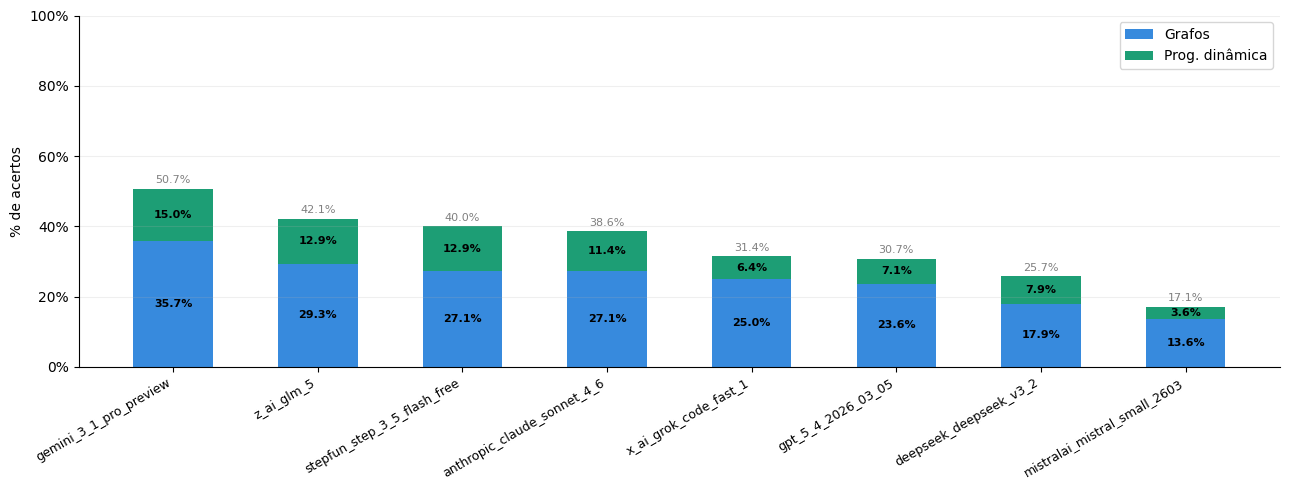

In [92]:
modelos = list(data_by_dataset.keys())
modelos_sorted = sorted(data_by_dataset.keys(), key=lambda k: data_by_dataset[k]['g'] + data_by_dataset[k]['pd'], reverse=True)
modelos = modelos_sorted
raw_g  = [data_by_dataset[k]['g']  for k in modelos]
raw_pd = [data_by_dataset[k]['pd'] for k in modelos]
g_pct  = [v / (len_g + len_pd) * 100 for v in raw_g]
pd_pct = [v / (len_g + len_pd) * 100 for v in raw_pd]

x = np.arange(len(modelos))
w = 0.55

fig, ax = plt.subplots(figsize=(13, 5))
bars_g  = ax.bar(x, g_pct,  w, label='Grafos',         color='#378ADD')
bars_pd = ax.bar(x, pd_pct, w, label='Prog. dinâmica', color='#1D9E75', bottom=g_pct)

for i in range(len(modelos)):
    # % dentro da barra de grafos
    if g_pct[i] > 3:
        ax.text(x[i], g_pct[i] / 2, f'{g_pct[i]:.1f}%',
                ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    # % dentro da barra de prog. dinâmica
    if pd_pct[i] > 3:
        ax.text(x[i], g_pct[i] + pd_pct[i] / 2, f'{pd_pct[i]:.1f}%',
                ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    # % total acima da barra
    total = g_pct[i] + pd_pct[i]
    ax.text(x[i], total + 1, f'{total:.1f}%',
            ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% de acertos')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()